# Using ROCS Scorer in DrugEx RNN

how to integrate the ROCS scorer into a DrugEx RNN workflow

- Configuring both CPU‑fallback (ez_rocs) and GPU‑accelerated (fastrocs) scorers with an .sq query  
- Scoring and visualizing example SMILES  
- Building a multi‑objective environment combining ROCS similarity and synthetic‑accessibility  
- Fine‑tuning and reinforcement‑learning of an RNN generator  
- Evaluating generated molecules (desired count, average scores, top hits) and comparing GPU vs. CPU performance  

## Prerequisites

To run this notebook, you need:
1. The DrugEx package installed
2. OpenEye toolkit with a valid license
3. A ROCS query file (.sq format)

## 1. Setting Up ROCS Scorer



In [1]:
from drugex.training.scorers.ez_rocs import RocsScorer
from drugex.training.scorers.fastrocs import OpenEyeScorer
import os
from rdkit.Chem import PandasTools
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your ROCS query file (.sq format)
# Get the absolute path to your model files
current_dir = Path(os.path.dirname(os.path.abspath("__file__")))  # Gets notebook directory
models_dir = current_dir / "models"

# List all .sq files and convert to absolute paths
sq_files = [str(f.absolute()) for f in models_dir.glob("*.sq")]

print(f"Found {len(sq_files)} ROCS query files:")
for i, f in enumerate(sq_files):
    print(f"  {i+1}. {os.path.basename(f)}")




OpenEye memory pool initialized in ez_rocs module
Found 6 ROCS query files:
  1. 3.sq
  2. 1.sq
  3. 5.sq
  4. model3-4_v1.sq
  5. 2.sq
  6. 4.sq


In [2]:
# choose just models with name '3.sq' and '4.sq'
sq_files = [f for f in sq_files if os.path.basename(f).startswith('3.sq') or os.path.basename(f).startswith('4.sq')]
print(sq_files)

['/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/models/3.sq', '/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/models/4.sq']


In [ ]:
sq_files = ['models/5.sq','models/1.sq','models/3.sq', 'models/4.sq']

# Initialize the ROCS scorer
ez_rocs_scorer = RocsScorer(
    query_file=sq_files,                # Path to the .sq model file
    experiment_name="ccr2_experiment",   # Name for temporary files
    score_type="TanimotoCombo",         # Type of score to extract (TanimotoCombo, ShapeTanimoto, or ColorTanimoto)
    use_gpu=True,
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=10,   # number of conformers to generate per molecule
    cpu_processes=1,     # this is used when use_gpu is False
    
    # top_n_models=2,      # Number of top performing models to use for scoring. Models are ranked by their 
                        # exponential moving average scores, which are updated based on scoring results
                        # from small batches of molecules. This allows the scorer to adaptively focus
                        # on the most effective models during training.
    
    # parallel_execution=True  # always True - whether to score with multiple models in parallel
)

fastrocs_scorer = OpenEyeScorer(
    sq_model_path=sq_files,
    use_gpu=True,           # when use_gpu is False, will all available CPU -2 !!!! This can cause OOM error
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=10,
)


ROCS scorer initialized using GPU mode with 4 shape query files
FastROCS GPU mode   : ON  (single process)


In [4]:
from openeye import oefastrocs
print("GPU ready?", oefastrocs.OEFastROCSIsGPUReady())

GPU ready? True


### Key Parameters of RocsScorer

The `RocsScorer` class accepts several parameters to customize its behavior:

- `sq_model_path`: Path to the ROCS query file (.sq format)
- `experiment_name`: Name for temporary files created during scoring
- `score_type`: Type of score to return. Options include:
  - `"TanimotoCombo"`: Combined shape and color score (default)
  - `"ShapeTanimoto"`: Shape-only similarity score
  - `"ColorTanimoto"`: Color (chemical features) similarity score
- `use_gpu`: Whether to use GPU acceleration (default: False)
- `max_isomers`: Maximum number of isomers to enumerate per molecule (default: 4)
- `max_rot_bonds`: Maximum number of rotatable bonds to consider (default: 10)
- `max_heavy_atoms`: Maximum number of heavy atoms to process (default: 30)
- `cpu_processes`: Number of CPU processes to use if not using GPU (default: 1)

## 2. Basic Usage: Scoring Molecules

Let's score some example molecules to see how the ROCS scorer works.

In [5]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = fastrocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nfastrocs_Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'fastrocs_Score': scores
})
results_df

Omega GPU mode enabled for conformer generation
FastROCS GPU mode enabled for shape queries
Preparing 20 molecules for GPU processing...
FastROCS GPU mode enabled for shape queries
Preparing 20 molecules for GPU processing...
FastROCS GPU mode enabled for shape queries
Preparing 20 molecules for GPU processing...
FastROCS GPU mode enabled for shape queries
Preparing 20 molecules for GPU processing...
SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
fastrocs_Score: 0.5666

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
fastrocs_Score: 0.7984



,SMILES,fastrocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.566568
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.798382


In [6]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = ez_rocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nez_rocs Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'ez_rocs_Score': scores
})
results_df

SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
ez_rocs Score: 0.5661

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
ez_rocs Score: 0.7971



,SMILES,ez_rocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.566085
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.797081


### Visualizing the Results



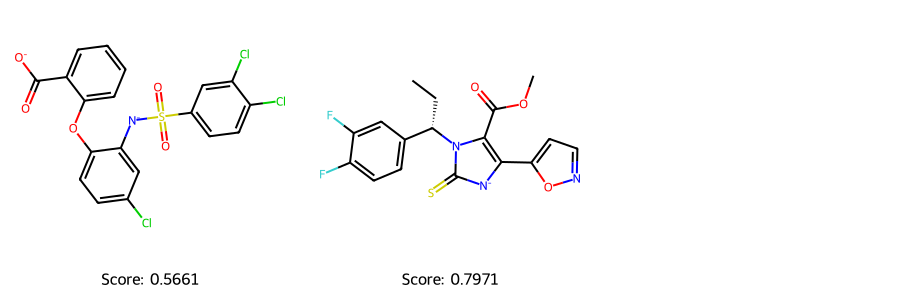

In [7]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES to RDKit molecules
mols = [Chem.MolFromSmiles(smi) for smi in test_smiles]

# Create labels with scores
legends = [f"Score: {score:.4f}" for score in scores]

# Display molecules with their scores
img = Draw.MolsToGridImage(mols, molsPerRow=3, legends=legends, subImgSize=(300, 300))
img

## 3. Integration with DrugEx RNN



In [8]:
# Import additional required modules
from drugex.training.environment import DrugExEnvironment
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.properties import Property
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor

# Path to pretrained model (adjust as needed)
GPUS = [0]  # Use GPU 0
MODELS_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT"

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

# Load pretrained model
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


### Creating a Multi-Objective Environment


1. ROCS similarity (higher is better)
2. Synthetic accessibility (lower is better, using the SA score)

# Here will be needed to tweak the clipping correctly, set too low for now, 


## two types of scorers ez_rocs is a base and fastrocs is gpu optimized "hopefully"

## maybe would be beneficial to think about the setting for filtering bad molecules or those you do not want so will not spend time do shape-match them 

In [9]:
# Synthetic Accessibility Scorer (1-10 scale, lower = better)
sa_scorer = Property("SA")
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))  # Matches your graph

# ROCS Combo Scorer (0-2 scale, higher = better)
# rocs_scorer = Property("ROCS")
# rocs_scorer.setModifier(SmoothClippedScore(lower_x=0.5, upper_x=1.5))  # Prioritize scores 0.5-1.5

# Calculate normalized threshold for desired real ROCS ≥ 1.0
# Formula: (real_score - lower_x) / (upper_x - lower_x)
rocs_threshold = (1.0 - 0.5) / (1.5 - 0.5)  # = 0.5

# Thresholds in normalized scores (0-1)
thresholds = [
    0.35,    # ROCS: Real score ≥1.0 → normalized 0.5
    0.1     # SA: Real score ≤3.9 → normalized 0.3
]


In [10]:
# --------------------------
# Multi-Objective Optimization
# --------------------------
scorer_ez = [ez_rocs_scorer, sa_scorer]
fastrocs_scorer = [fastrocs_scorer, sa_scorer]


# **Choose scorer:**

## we will use the robust stable version of the scorer fastrocs import OpenEyeScorer


In [11]:
# Create environment with Pareto optimization
env = DrugExEnvironment(
    scorers=fastrocs_scorer,  # fastrocs_scorer , scorer_ez
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()  # Multi-objective optimization scheme
)

# Finetuning

In [12]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter, Standardization
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
import multiprocessing as mp
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet


CPU_COUNT     = max(1, mp.cpu_count() - 2)  
MODEL_DIR_RL = "./rocs_rl_ccr"
if not os.path.exists(MODEL_DIR_RL):
    os.makedirs(MODEL_DIR_RL)
    
    
print(f"Fine-tuning device: {'GPU' if GPUS else 'CPU'} (GPUS: {GPUS})")

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')
data_path = "CCR_HUMAN_AL.tsv"
print(f"Loading fine-tuning data from {data_path}")
df = pd.read_csv(data_path, sep='\t')



Fine-tuning device: GPU (GPUS: [0])
Loading fine-tuning data from CCR_HUMAN_AL.tsv


In [13]:
if 'SMILES' not in df.columns:
    print(f"ERROR: No 'SMILES' column found in {data_path}")



X_train = df['SMILES'].values
model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
model.load_state_dict(pretrained.state_dict())

CHUNK_SIZE = 1024
BATCH_SIZE = 512
FT_EPOCHS = 100

standardizer = Standardization(n_proc=CPU_COUNT, chunk_size=CHUNK_SIZE)
valid_smiles = standardizer.apply(X_train)
print(f"Found {len(valid_smiles)} valid SMILES strings for training")
os.makedirs(MODEL_DIR_RL, exist_ok=True)
corpus_file = os.path.join(MODEL_DIR_RL, "corpus.tsv")
voc_file = os.path.join(MODEL_DIR_RL, "model.vocab")
encoder = CorpusEncoder(
    SequenceCorpus,
    {'vocabulary': voc, 'update_voc': False, 'throw': True},
    n_proc=CPU_COUNT,
    chunk_size=CHUNK_SIZE
)

Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Found 1021 valid SMILES strings for training


In [14]:
data_collector = SmilesDataSet(corpus_file, rewrite=True)
encoder.apply(valid_smiles, collector=data_collector)
voc.toFile(voc_file)

print(f"Saved vocabulary to {voc_file}")
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())
for data, name in zip([train, test], ['train', 'test']):
    pd.DataFrame(data, columns=data_collector.getColumns()).to_csv(
        os.path.join(MODEL_DIR_RL, f'ligand_{name}.tsv'),
        header=True, index=False, sep='\t'
    )

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'O', 'c', 'EOS', '1', 'S', '3', '(', ')', 'F', 'C', '2', 'L', '=', 'N'} (occurrence count: 102). It will be ignored.


Saved vocabulary to ./rocs_rl_ccr/model.vocab


## Uncomment for finetuning

In [15]:
# data_set_train = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_train.tsv'), voc=voc)
# train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
# data_set_test = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_test.tsv'), voc=voc)
# valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)
# print(f"Fine-tuning model for {FT_EPOCHS} epochs")

# model.fit(train_loader, valid_loader, epochs=FT_EPOCHS,
#              monitor=FileMonitor(
#                  f"{MODEL_DIR_RL}/finetune", 
#                  save_smiles=True,
#                  reset_directory=True
#                  ))

# os.makedirs(MODEL_DIR_RL, exist_ok=True)
# model_path = f'{MODEL_DIR_RL}/finetune.pkg'
# voc.toFile(f'{MODEL_DIR_RL}/finetune.vocab')
# print(f"Model saved to {model_path}")
# print("Fine-tuning completed successfully")


### Setting Up Reinforcement Learning



In [16]:
try:
    vocab_path = f'{MODEL_DIR_RL}/finetune.vocab'
    voc = VocSmiles.fromFile(vocab_path, encode_frags=False)
except FileNotFoundError:
    print("Finetuned vocabulary not found, using pretrained vocabulary instead")
    voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

try:
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODEL_DIR_RL}/finetune.pkg')
except FileNotFoundError:
    print("Finetuned model not found, using pretrained model instead")
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


In [17]:
explorer = SequenceExplorer(
    agent=finetuned,
    env=env,
    mutate=pretrained,
    epsilon=0.1,
    batch_size=100,
    n_samples=100,
    use_gpus=GPUS
)

# Set up output directory for training logs
os.makedirs(MODEL_DIR_RL, exist_ok=True)

# Configure monitor to track progress
monitor = FileMonitor(
    f"{MODEL_DIR_RL}/rocs_agent", 
    save_smiles=True,          # Save generated SMILES
    reset_directory=True       # Clear previous results
)

Removing rocs_agent_fit.log from ./rocs_rl_ccr
Removing rocs_agent_fit.tsv from ./rocs_rl_ccr
Removing rocs_agent_smiles.tsv from ./rocs_rl_ccr
Removing rocs_agent.pkg from ./rocs_rl_ccr


### Training the Model


In [18]:
# Run reinforcement learning (in practice, use more epochs, e.g., 30-100)
explorer.fit(monitor=monitor, epochs=10, patience=10)

# Load training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')


Fitting SMILES RNN explorer:   0%|          | 0/10 [00:00<?, ?it/s]

Preparing 117 molecules for GPU processing...
Preparing 180 molecules for GPU processing...
Preparing 153 molecules for GPU processing...
Preparing 10 molecules for GPU processing...
Preparing 117 molecules for GPU processing...
Preparing 180 molecules for GPU processing...
Preparing 153 molecules for GPU processing...
Preparing 10 molecules for GPU processing...
Preparing 117 molecules for GPU processing...
Preparing 180 molecules for GPU processing...
Preparing 153 molecules for GPU processing...
Preparing 10 molecules for GPU processing...
Preparing 117 molecules for GPU processing...
Preparing 180 molecules for GPU processing...
Preparing 153 molecules for GPU processing...
Preparing 10 molecules for GPU processing...


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Preparing 120 molecules for GPU processing...
Preparing 120 molecules for GPU processing...
Preparing 120 molecules for GPU processing...
Preparing 120 molecules for GPU processing...
Preparing 81 molecules for GPU processing...
Preparing 89 molecules for GPU processing...
Preparing 130 molecules for GPU processing...
Preparing 10 molecules for GPU processing...
Preparing 81 molecules for GPU processing...
Preparing 89 molecules for GPU processing...
Preparing 130 molecules for GPU processing...
Preparing 10 molecules for GPU processing...
Preparing 81 molecules for GPU processing...
Preparing 89 molecules for GPU processing...
Preparing 130 molecules for GPU processing...
Preparing 10 molecules for GPU processing...
Preparing 81 molecules for GPU processing...
Preparing 89 molecules for GPU processing...
Preparing 130 molecules for GPU processing...
Preparing 10 molecules for GPU processing...


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

...

Preparing 82 molecules for GPU processing...
Preparing 82 molecules for GPU processing...
Preparing 82 molecules for GPU processing...
Preparing 82 molecules for GPU processing...
Preparing 310 molecules for GPU processing...
Preparing 278 molecules for GPU processing...
Preparing 384 molecules for GPU processing...
Preparing 140 molecules for GPU processing...
Preparing 310 molecules for GPU processing...
Preparing 278 molecules for GPU processing...
Preparing 384 molecules for GPU processing...
Preparing 140 molecules for GPU processing...
Preparing 310 molecules for GPU processing...
Preparing 278 molecules for GPU processing...
Preparing 384 molecules for GPU processing...
Preparing 140 molecules for GPU processing...
Preparing 310 molecules for GPU processing...
Preparing 278 molecules for GPU processing...
Preparing 384 molecules for GPU processing...
Preparing 140 molecules for GPU processing...


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Preparing 124 molecules for GPU processing...
Preparing 124 molecules for GPU processing...
Preparing 124 molecules for GPU processing...
Preparing 124 molecules for GPU processing...
Preparing 346 molecules for GPU processing...
Preparing 272 molecules for GPU processing...
Preparing 369 molecules for GPU processing...
Preparing 113 molecules for GPU processing...
Preparing 346 molecules for GPU processing...
Preparing 272 molecules for GPU processing...
Preparing 369 molecules for GPU processing...
Preparing 113 molecules for GPU processing...
Preparing 346 molecules for GPU processing...
Preparing 272 molecules for GPU processing...
Preparing 369 molecules for GPU processing...
Preparing 113 molecules for GPU processing...
Preparing 346 molecules for GPU processing...
Preparing 272 molecules for GPU processing...
Preparing 369 molecules for GPU processing...
Preparing 113 molecules for GPU processing...


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Preparing 118 molecules for GPU processing...
Preparing 118 molecules for GPU processing...
Preparing 118 molecules for GPU processing...
Preparing 118 molecules for GPU processing...


In [19]:
training_df.head(50)

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.7,0.7,0.7,0.725,0.699,0.226,1
1,2,0.7,0.7,0.7,0.691,0.666,0.121,1
2,3,0.9,0.9,0.8,0.614,0.563,0.038,3
3,4,0.7,0.7,0.6,0.672,0.640,0.035,3
4,5,0.6,0.6,0.5,0.613,0.575,0.054,3
5,6,0.7,0.7,0.7,0.733,0.698,0.042,3
6,7,0.7,0.7,0.7,0.724,0.704,0.053,3
7,8,0.8,0.8,0.8,0.690,0.667,0.058,3
8,9,0.8,0.8,0.8,0.673,0.643,0.063,3
9,10,1.0,1.0,1.0,0.705,0.679,0.073,10


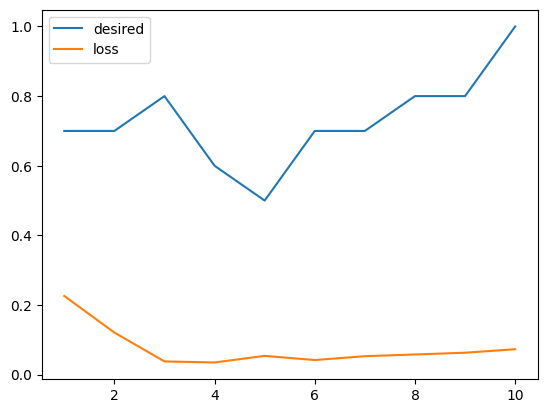

In [20]:
# linear plot of the training progress
plt.plot(training_df['Epoch'], training_df['desired_ratio'], label='desired')
plt.plot(training_df['Epoch'], training_df['loss_train'], label='loss')
plt.legend()
plt.show()


In [21]:
# Load the trained model
optimized_model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
optimized_model.loadStatesFromFile(f"{MODEL_DIR_RL}/rocs_agent.pkg")

# Generate molecules
generated = optimized_model.generate(num_samples=1000)


Generating molecules:   0%|          | 0/1000 [00:00<?, ?it/s]

Preparing 397 molecules for GPU processing...
Preparing 325 molecules for GPU processing...
Preparing 395 molecules for GPU processing...
Preparing 441 molecules for GPU processing...
Preparing 441 molecules for GPU processing...
Preparing 458 molecules for GPU processing...
Preparing 388 molecules for GPU processing...
Preparing 356 molecules for GPU processing...
Preparing 330 molecules for GPU processing...
Preparing 503 molecules for GPU processing...
Preparing 423 molecules for GPU processing...
Preparing 385 molecules for GPU processing...
Preparing 364 molecules for GPU processing...
Preparing 369 molecules for GPU processing...
Preparing 386 molecules for GPU processing...
Preparing 328 molecules for GPU processing...
Preparing 394 molecules for GPU processing...
Preparing 339 molecules for GPU processing...
Preparing 434 molecules for GPU processing...
Preparing 356 molecules for GPU processing...
Preparing 482 molecules for GPU processing...
Preparing 384 molecules for GPU pr

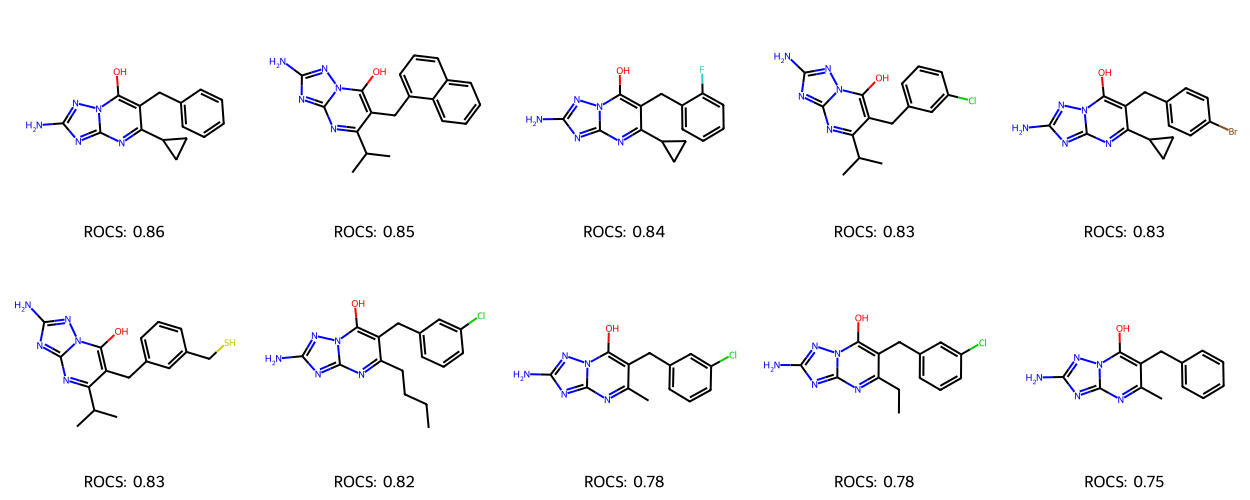

In [22]:
generated_smiles = generated.SMILES.tolist()

# Score the generated molecules
scores = env.getScores(generated_smiles)
scores_df = pd.DataFrame(scores)

# Display summary statistics
print(f"Generated {len(generated_smiles)} molecules")
print(f"Desirable molecules: {scores_df['Desired'].sum()} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"Average ROCS score: {scores_df['ROCS'].mean():.4f}")
print(f"Average SA score: {scores_df['SA'].mean():.4f}")

# Show top 10 molecules by ROCS score
top_by_rocs = scores_df.sort_values('ROCS', ascending=False).head(10)
top_indices = top_by_rocs.index.tolist()
top_smiles = [generated_smiles[i] for i in top_indices]
top_scores = top_by_rocs['ROCS'].tolist()

# Convert to RDKit molecules and display
top_mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ROCS: {score:.2f}" for score in top_scores]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
# Filter for molecules with ROCS score above 0.7
high_rocs = scores_df[scores_df['ROCS'] > 0.7].sort_values('ROCS', ascending=False).head(10)
high_indices = high_rocs.index.tolist()
high_smiles = [generated_smiles[i] for i in high_indices]
high_scores = high_rocs['ROCS'].tolist()

# Convert filtered molecules to RDKit mols and display
high_mols = [Chem.MolFromSmiles(smi) for smi in high_smiles]
legends = [f"ROCS: {score:.2f}" for score in high_scores]
img = Draw.MolsToGridImage(high_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
img




Some key steps were:

1. Setting up the ROCS scorer with an appropriate shape query (.sq file)
2. Scoring molecules to evaluate their 3D shape similarity
3. Integrating the scorer into a DrugEx, finetuning and reinforcement learning pipeline
4. Training a model to generate molecules with high shape similarity
5. Evaluating the results and considering performance optimizations

